<a href="https://colab.research.google.com/github/elenarieee/PCD_Assignment01/blob/main/PCD_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

fotoPCD1.jpg shape: (213, 320, 3)


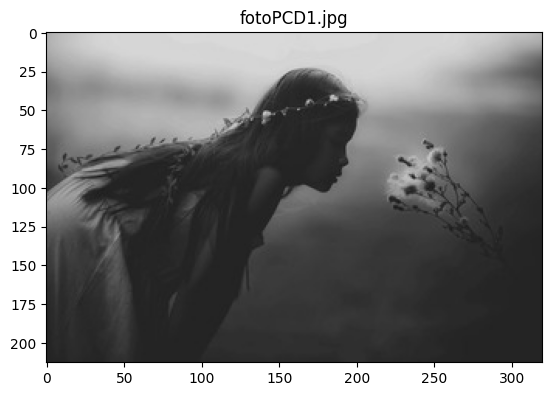

fotoPCD2.jpg shape: (803, 1199, 3)


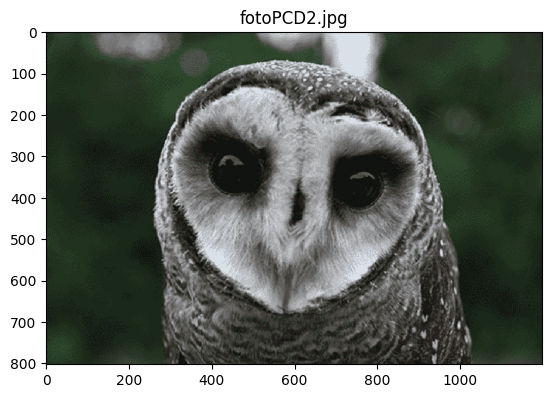

fotoPCD3.jpg shape: (452, 678, 3)


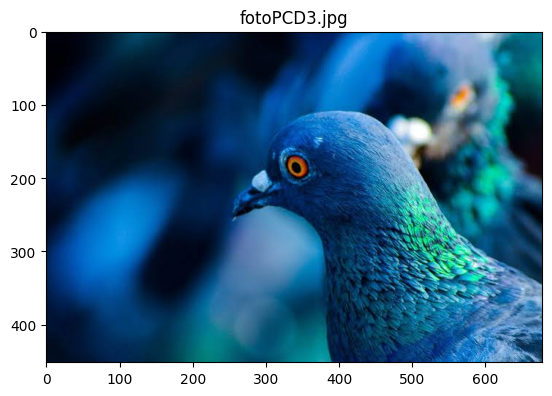

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

daftar_file = ["fotoPCD1.jpg", "fotoPCD2.jpg", "fotoPCD3.jpg"]
daftar_citra = [cv2.cvtColor(cv2.imread(f), cv2.COLOR_BGR2RGB) for f in daftar_file]

for nama_file, citra in zip(daftar_file, daftar_citra):
    print(nama_file, "shape:", citra.shape)
    plt.imshow(citra)
    plt.title(nama_file)
    plt.show()

# DOWN SAMPLING

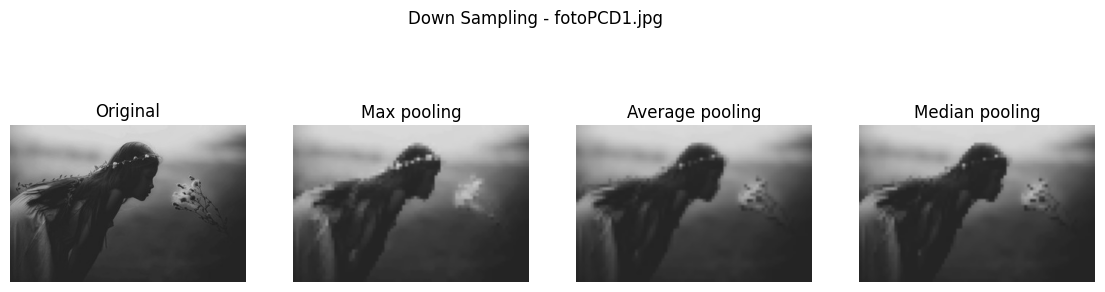

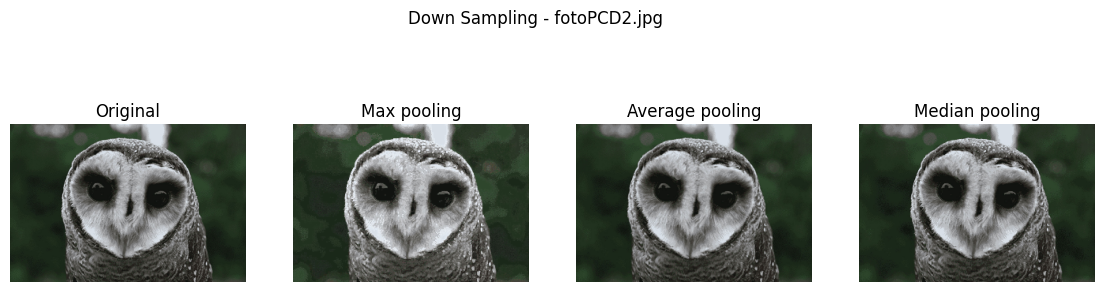

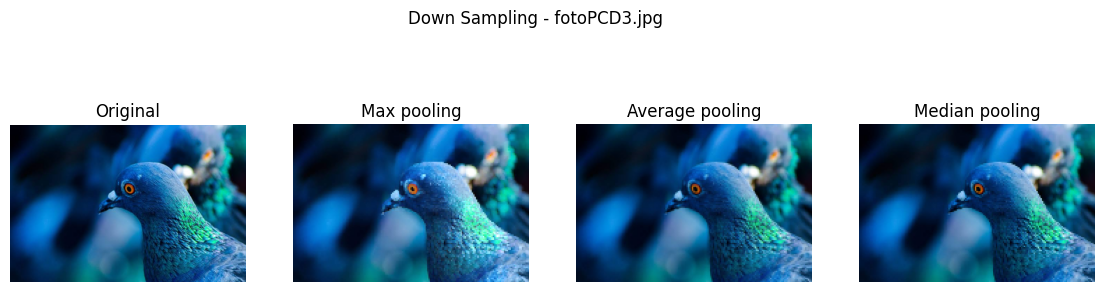

In [17]:
def downsample(citra, ukuran_blok, metode):
    tinggi, lebar = citra.shape[0], citra.shape[1]
    tinggi_baru, lebar_baru = tinggi // ukuran_blok, lebar // ukuran_blok
    hasil = np.zeros((tinggi_baru, lebar_baru, 3), dtype=np.uint8)
    for i in range(0, tinggi_baru):
        for j in range(0, lebar_baru):
            blok = citra[i*ukuran_blok:(i+1)*ukuran_blok, j*ukuran_blok:(j+1)*ukuran_blok]
            if metode == "max":
                hasil[i, j] = blok.max(axis=(0, 1))
            elif metode == "average":
                hasil[i, j] = blok.mean(axis=(0, 1))
            elif metode == "median":
                hasil[i, j] = np.median(blok, axis=(0, 1))
    return hasil

ukuran_blok = 4
hasil_downsample = {}

for nama_file, citra in zip(daftar_file, daftar_citra):
    hasil_downsample[nama_file] = {}
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    axes[0].imshow(citra); axes[0].set_title("Original"); axes[0].axis('off')
    for ax, metode in zip(axes[1:], ["max", "average", "median"]):
        citra_kecil = downsample(citra, ukuran_blok, metode)
        hasil_downsample[nama_file][metode] = citra_kecil
        ax.imshow(citra_kecil)
        ax.set_title(f"{metode.capitalize()} pooling")
        ax.axis('off')
    plt.suptitle(f"Down Sampling - {nama_file}")
    plt.show()


# UP SAMPLING

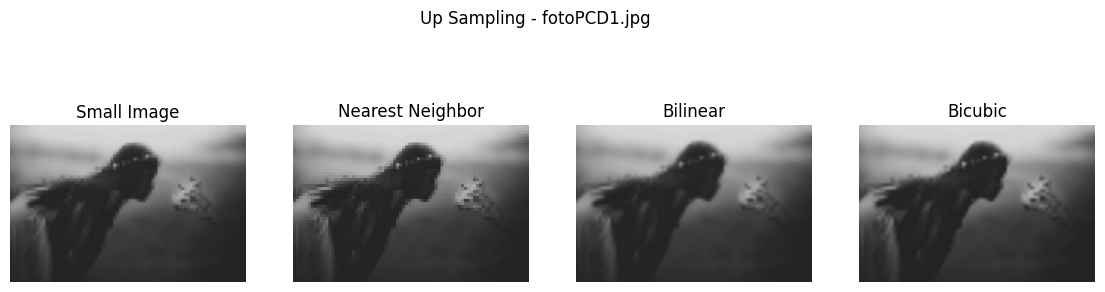

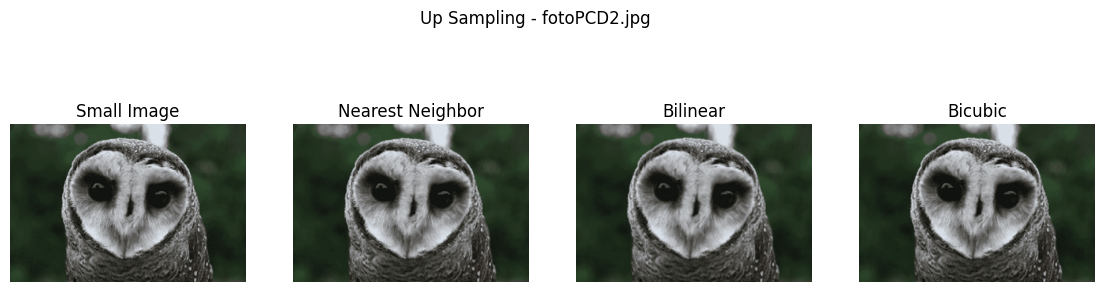

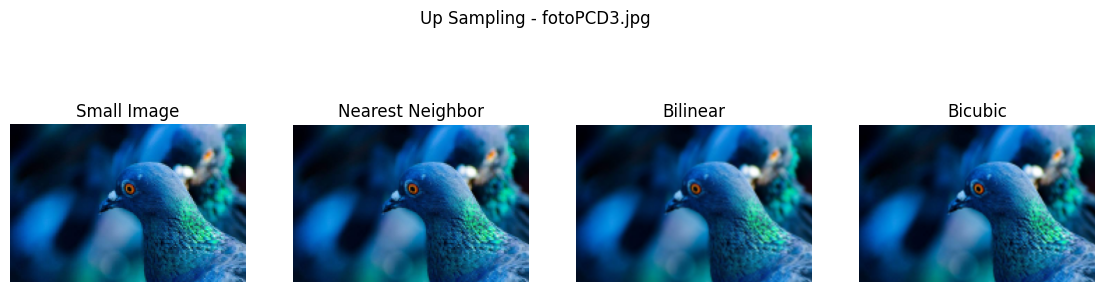

In [20]:
def upsample_nn(citra, tinggi_baru, lebar_baru):
    tinggi, lebar = citra.shape[0], citra.shape[1]
    hasil = np.zeros((tinggi_baru, lebar_baru, 3), dtype=np.uint8)
    for i in range(tinggi_baru):
        for j in range(lebar_baru):
            hasil[i, j] = citra[min(i * tinggi // tinggi_baru, tinggi - 1), min(j * lebar // lebar_baru, lebar - 1)]
    return hasil

def upsample_bilinear(citra, tinggi_baru, lebar_baru):
    tinggi, lebar = citra.shape[0], citra.shape[1]
    citra = citra.astype(np.float64)
    hasil = np.zeros((tinggi_baru, lebar_baru, 3), dtype=np.float64)
    for i in range(tinggi_baru):
        y = i * (tinggi - 1) / (tinggi_baru - 1)
        y0, y1 = int(np.floor(y)), min(int(np.floor(y)) + 1, tinggi - 1)
        bobot_y = y - y0
        for j in range(lebar_baru):
            x = j * (lebar - 1) / (lebar_baru - 1)
            x0, x1 = int(np.floor(x)), min(int(np.floor(x)) + 1, lebar - 1)
            bobot_x = x - x0
            atas = citra[y0, x0] * (1 - bobot_x) + citra[y0, x1] * bobot_x
            bawah = citra[y1, x0] * (1 - bobot_x) + citra[y1, x1] * bobot_x
            hasil[i, j] = atas * (1 - bobot_y) + bawah * bobot_y
    return hasil.astype(np.uint8)

def bobot_kubik(jarak, a=-0.5):
    jarak = abs(jarak)
    if jarak <= 1:
        return (a + 2) * (jarak**3) - (a + 3) * (jarak**2) + 1
    elif jarak < 2:
        return a * (jarak**3) - 5 * a * (jarak**2) + 8 * a * jarak - 4 * a
    return 0

def upsample_bicubic(citra, tinggi_baru, lebar_baru):
    tinggi, lebar = citra.shape[0], citra.shape[1]
    citra = citra.astype(np.float64)
    hasil = np.zeros((tinggi_baru, lebar_baru, 3), dtype=np.float64)

    for i in range(tinggi_baru):
        y = i * (tinggi - 1) / (tinggi_baru - 1)
        y_int = int(np.floor(y))
        for j in range(lebar_baru):
            x = j * (lebar - 1) / (lebar_baru - 1)
            x_int = int(np.floor(x))

            nilai = np.zeros(3)
            for m in range(-1, 3):
                for n in range(-1, 3):
                    px = min(max(x_int + m, 0), lebar - 1)
                    py = min(max(y_int + n, 0), tinggi - 1)

                    wx = bobot_kubik(x - (x_int + m))
                    wy = bobot_kubik(y - (y_int + n))

                    nilai += citra[py, px] * wx * wy

            hasil[i, j] = nilai

    return np.clip(hasil, 0, 255).astype(np.uint8)

for nama_file, citra in zip(daftar_file, daftar_citra):
    tinggi, lebar = citra.shape[0], citra.shape[1]
    citra_kecil = hasil_downsample[nama_file]["average"]

    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    axes[0].imshow(citra_kecil); axes[0].set_title("Small Image"); axes[0].axis('off')

    hasil_nn = upsample_nn(citra_kecil, tinggi, lebar)
    hasil_bilinear = upsample_bilinear(citra_kecil, tinggi, lebar)
    hasil_bicubic = upsample_bicubic(citra_kecil, tinggi, lebar)

    for ax, metode, hasil in zip(axes[1:], ["Nearest Neighbor", "Bilinear", "Bicubic"], [hasil_nn, hasil_bilinear, hasil_bicubic]):
        ax.imshow(hasil)
        ax.set_title(metode)
        ax.axis('off')
    plt.suptitle(f"Up Sampling - {nama_file}")
    plt.show()